# Transformer

Dataset de señales EMG para clasificación de 4 gestos de la mano:
- 0 --> Piedra
- 1 --> Tijera
- 2 --> Papel
- 3 --> Ok

64 columnas 8 canales EMG x 8 intentes de tiempo por ventana.

## Imports y config

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings

warnings.filterwarnings('ignore')

c:\Users\Rocío\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import csr_matrix, issparse


In [2]:
random_state = 42
np.random.seed(random_state)

## Carga dataset

In [3]:
df_0 = pd.read_csv("data/0.csv", header=None)
df_1 = pd.read_csv("data/1.csv", header=None)
df_2 = pd.read_csv("data/2.csv", header=None)
df_3 = pd.read_csv("data/3.csv", header=None)

dfs_por_clase = {0: df_0, 1: df_1, 2: df_2, 3: df_3}

df = pd.concat([df_0, df_1, df_2, df_3], ignore_index=True)

# Se cambia nombre de las columnas
sensor_cols = [f'S{i}' for i in range(64)]
df.columns = sensor_cols + ['label']
for k in dfs_por_clase:
    dfs_por_clase[k].columns = sensor_cols + ['label']

X = df[sensor_cols]
y = df['label']

## Entrenamiento y prueba

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Escalar datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Formato de X_train antes del Transformer: {X_train.shape}")

Formato de X_train antes del Transformer: (9342, 64)


## Transformer

In [5]:
# Redimensionar datos
X_train_3d = X_train.reshape(-1, 8, 8) # (N, 8 tiempos, 8 canales)
X_test_3d = X_test.reshape(-1, 8, 8)

# NumPy -> PyTorch
X_train_tensor = torch.tensor(X_train_3d, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_3d, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Ahorra todo el coste computacional de preprocesar TD/FD, ya que aprende las características óptimas directamente de la secuencia en bruto.

In [6]:
# Transformer
class EMGTransformer(nn.Module):
    def __init__(self, input_size=8, d_model=32, nhead=4, num_layers=2, num_classes=4):
        super(EMGTransformer, self).__init__()
        
        # 8 canales -> Tamaño Transformer
        self.embedding = nn.Linear(input_size, d_model)
        
        # Positional encoding -> longitud 8
        self.positional_encoding = nn.Parameter(torch.randn(1, 8, d_model))
        
        # Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Salida
        self.fc = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        # (Batch, 8, 8) -> (Batch, 8, 32)
        x = self.embedding(x)
        x = x + self.positional_encoding # + tiempo
        
        x = self.transformer_encoder(x)
        
        # Media tiempo -> (Batch, 32)
        x = x.mean(dim=1)
        # (Batch, 32) -> (Batch, 4)
        x = self.fc(x)
        return x

In [7]:
model = EMGTransformer()

# CrossEntropy para clasificar y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 25
historial_loss = [] # Para graficar

start_train = time.time()
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad() # Limpiar gradientes
        outputs = model(batch_X) # Prediccion
        loss = criterion(outputs, batch_y) # Error
        loss.backward() # Backpropagation
        optimizer.step() # Actualizar pesos
        total_loss += loss.item()

    loss_promedio = total_loss / len(train_loader)
    historial_loss.append(loss_promedio)
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss promedio: {total_loss/len(train_loader):.4f}")

end_train = time.time() 
tiempo_training_total = end_train - start_train

# Evaluacion
model.eval()
correct = 0
total = 0

with torch.no_grad(): # Desactivamos gradientes para evaluar más rápido
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy final del Transformer en Test: {accuracy:.2f}%")

Epoch 5/25 | Loss promedio: 0.0875
Epoch 10/25 | Loss promedio: 0.0618
Epoch 15/25 | Loss promedio: 0.0483
Epoch 20/25 | Loss promedio: 0.0321
Epoch 25/25 | Loss promedio: 0.0324
Accuracy final del Transformer en Test: 96.66%


### Añadir ruido

In [8]:
# Desviación estandar de X_test
std_test = np.std(X_test_3d)

# Ruido uniforme
noise = np.random.uniform(-0.3 * std_test, 0.3 * std_test, X_test_3d.shape)

X_test_noise_3d = X_test_3d + noise

# DataLoader para el ruido
X_test_noise_tensor = torch.tensor(X_test_noise_3d, dtype=torch.float32)
test_noise_dataset = TensorDataset(X_test_noise_tensor, y_test_tensor)
test_noise_loader = DataLoader(test_noise_dataset, batch_size=32, shuffle=False)

### Latencia

In [9]:
def accuracy_and_latency_transformer(modelo, loader):
    modelo.eval()
    correct = 0
    total = 0
    latencias = []
    
    with torch.no_grad():
        for i in range(5): 
            start = time.time()
            
            for batch_X, batch_y in loader:
                outputs = modelo(batch_X)
                _, predicted = torch.max(outputs.data, 1)
                
                # Aciertos al final para no duplicar
                if i == 4:
                    total += batch_y.size(0)
                    correct += (predicted == batch_y).sum().item()
                    
            end = time.time()
            latencias.append(end - start)
            
    elapsed = np.mean(latencias)
    acc = correct / total
    return acc, elapsed

### Resultados

In [10]:
# Evaluar SIN ruido
acc_trans, time_trans = accuracy_and_latency_transformer(model, test_loader)

# Evaluar CON ruido
acc_trans_n, time_trans_n = accuracy_and_latency_transformer(model, test_noise_loader)

# Latencia media
lat_trans = (time_trans + time_trans_n) / 2

print("Resultados del transformer")
print(f"Accuracy sin ruido: {acc_trans:.4f}")
print(f"Accuracy con ruido: {acc_trans_n:.4f}")
print(f"Latencia media (s): {lat_trans:.4f}")
print(f"Tiempo de training: {tiempo_training_total:.2f} s")

Resultados del transformer
Accuracy sin ruido: 0.9666
Accuracy con ruido: 0.8943
Latencia media (s): 0.1958
Tiempo de training: 232.85 s


### Curva de aprendizaje epoch

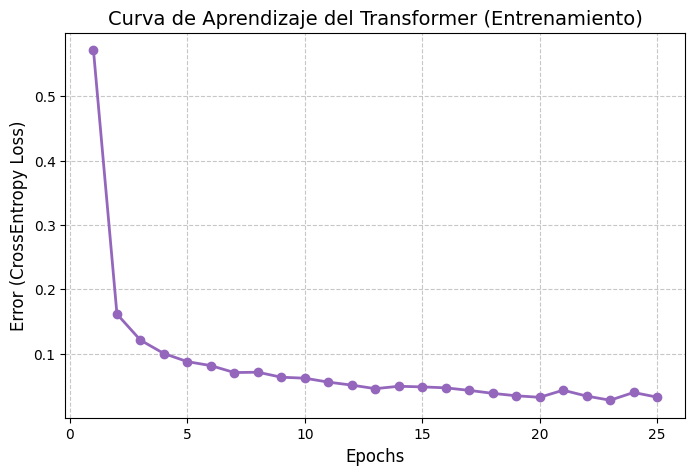

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), historial_loss, marker='o', color='tab:purple', linewidth=2)
plt.title('Curva de Aprendizaje del Transformer (Entrenamiento)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Error (CrossEntropy Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Matriz de confusión

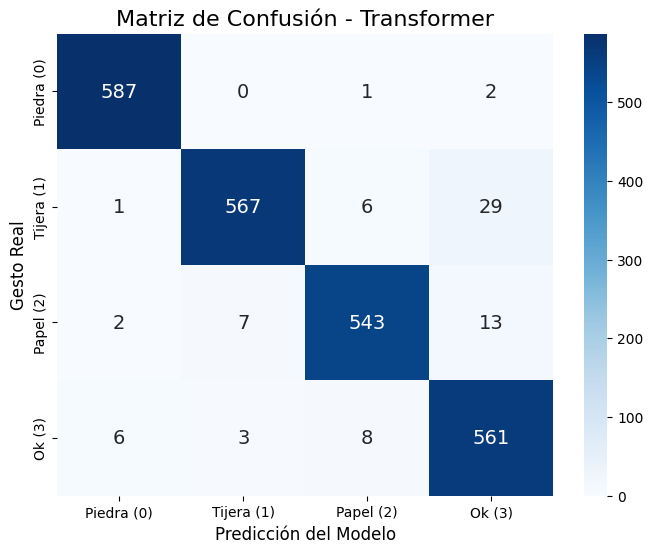

In [12]:
# Predicciones test
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(batch_y.numpy())

# Matriz
cm = confusion_matrix(all_labels, all_preds)
clases = ['Piedra (0)', 'Tijera (1)', 'Papel (2)', 'Ok (3)']

# Grafica
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases, yticklabels=clases, 
            annot_kws={"size": 14})

plt.title('Matriz de Confusión - Transformer', fontsize=16)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Gesto Real', fontsize=12)
plt.show()

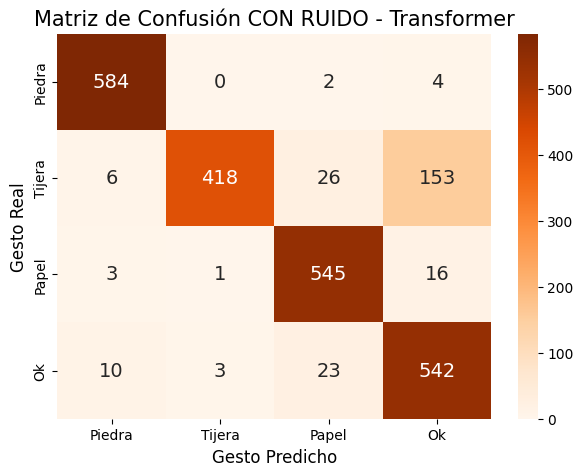

In [13]:
# Predicciones con ruido
model.eval()
all_preds_noise = []
all_targets_noise = []

with torch.no_grad():
    for batch_X, batch_y in test_noise_loader:
        outputs = model(batch_X)
        _, preds = torch.max(outputs.data, 1)
        all_preds_noise.extend(preds.numpy())
        all_targets_noise.extend(batch_y.numpy())

# Matriz de confusion
cm_noise = confusion_matrix(all_targets_noise, all_preds_noise)
nombres_gestos = ['Piedra', 'Tijera', 'Papel', 'Ok']

# Dibujar
plt.figure(figsize=(7, 5))
sns.heatmap(cm_noise, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=nombres_gestos, yticklabels=nombres_gestos,
            annot_kws={"size": 14})
plt.title('Matriz de Confusión CON RUIDO - Transformer', fontsize=15)
plt.ylabel('Gesto Real', fontsize=12)
plt.xlabel('Gesto Predicho', fontsize=12)
plt.show()

## Estudio de ablación - sin positional encoding

In [14]:
class EMGTransformer_SinTiempo(nn.Module):
    def __init__(self, input_size=8, d_model=32, nhead=4, num_layers=2, num_classes=4):
        super(EMGTransformer_SinTiempo, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)  
        # Sin x = x + self.positional_encoding
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        x = self.fc(x)
        return x

In [16]:
# Entrenar
model_ablation = EMGTransformer_SinTiempo()
criterion_ab = nn.CrossEntropyLoss()
optimizer_ab = torch.optim.Adam(model_ablation.parameters(), lr=0.001)

epochs_ab = 15
historial_loss_ab = [] # Para graficar

start_train = time.time()
for epoch in range(epochs_ab):
    model_ablation.train()
    for batch_X, batch_y in train_loader:
        optimizer_ab.zero_grad()               
        outputs = model_ablation(batch_X)            
        loss = criterion_ab(outputs, batch_y)  
        loss.backward()                     
        optimizer_ab.step()
    
    loss_promedio = total_loss / len(train_loader)
    historial_loss_ab.append(loss_promedio)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs_ab} | Loss promedio: {total_loss/len(train_loader):.4f}")

end_train = time.time() 
tiempo_training_total = end_train - start_train

# Evaluar
model_ablation.eval()
correct_ab = 0
total_ab = 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model_ablation(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        total_ab += batch_y.size(0)
        correct_ab += (predicted == batch_y).sum().item()

accuracy_ab = 100 * correct_ab / total_ab
print(f"Accuracy de la ABLACIÓN (Sin tiempo): {(accuracy_ab):.2f}%")

Epoch 5/15 | Loss promedio: 0.0324
Epoch 10/15 | Loss promedio: 0.0324
Epoch 15/15 | Loss promedio: 0.0324
Accuracy de la ABLACIÓN (Sin tiempo): 97.52%


### Añadir ruido

In [17]:
# Desviación estandar de X_test
std_test = np.std(X_test_3d)

# Ruido uniforme
noise = np.random.uniform(-0.3 * std_test, 0.3 * std_test, X_test_3d.shape)

X_test_noise_3d = X_test_3d + noise

# DataLoader para el ruido
X_test_noise_tensor = torch.tensor(X_test_noise_3d, dtype=torch.float32)
test_noise_dataset = TensorDataset(X_test_noise_tensor, y_test_tensor)
test_noise_loader = DataLoader(test_noise_dataset, batch_size=32, shuffle=False)

### Resultados

In [18]:
# Evaluar SIN ruido
acc_trans, time_trans = accuracy_and_latency_transformer(model, test_loader)

# Evaluar CON ruido
acc_trans_n, time_trans_n = accuracy_and_latency_transformer(model, test_noise_loader)

# Latencia media
lat_trans = (time_trans + time_trans_n) / 2

print("Resultados del transformer")
print(f"Accuracy sin ruido: {acc_trans:.4f}")
print(f"Accuracy con ruido: {acc_trans_n:.4f}")
print(f"Latencia media (s): {lat_trans:.4f}")
print(f"Tiempo de training: {tiempo_training_total:.2f} s")

Resultados del transformer
Accuracy sin ruido: 0.9666
Accuracy con ruido: 0.9003
Latencia media (s): 0.1864
Tiempo de training: 153.48 s


### Curva de aprendizaje epoch

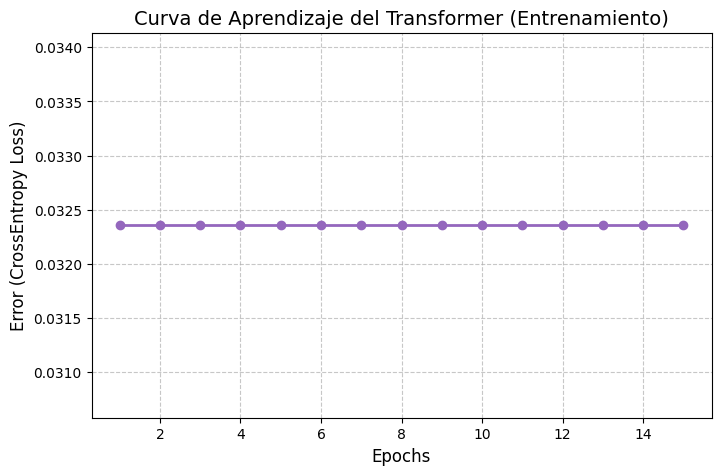

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_ab + 1), historial_loss_ab, marker='o', color='tab:purple', linewidth=2)
plt.title('Curva de Aprendizaje del Transformer (Entrenamiento)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Error (CrossEntropy Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Matrices de confusión

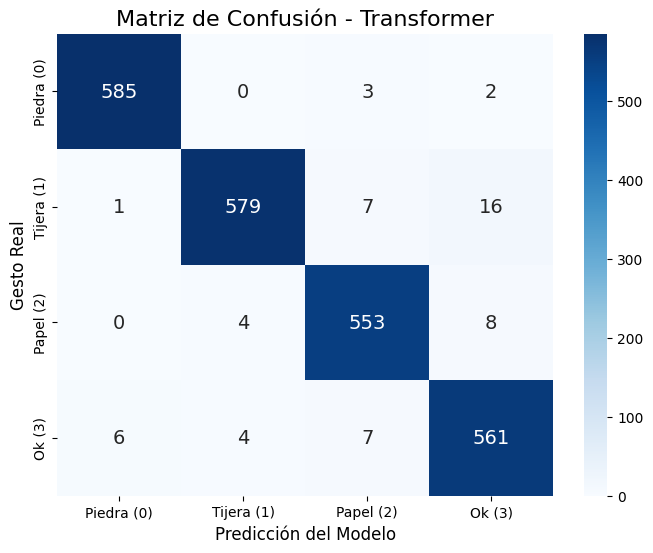

In [21]:
# Predicciones test
model_ablation.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model_ablation(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(batch_y.numpy())

# Matriz
cm = confusion_matrix(all_labels, all_preds)
clases = ['Piedra (0)', 'Tijera (1)', 'Papel (2)', 'Ok (3)']

# Grafica
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases, yticklabels=clases, 
            annot_kws={"size": 14})

plt.title('Matriz de Confusión - Transformer', fontsize=16)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Gesto Real', fontsize=12)
plt.show()

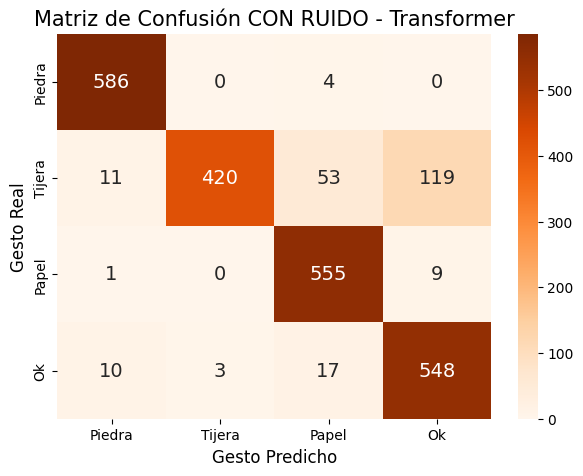

In [22]:
# Predicciones con ruido
model_ablation.eval()
all_preds_noise = []
all_targets_noise = []

with torch.no_grad():
    for batch_X, batch_y in test_noise_loader:
        outputs = model_ablation(batch_X)
        _, preds = torch.max(outputs.data, 1)
        all_preds_noise.extend(preds.numpy())
        all_targets_noise.extend(batch_y.numpy())

# Matriz de confusion
cm_noise = confusion_matrix(all_targets_noise, all_preds_noise)
nombres_gestos = ['Piedra', 'Tijera', 'Papel', 'Ok']

# Dibujar
plt.figure(figsize=(7, 5))
sns.heatmap(cm_noise, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=nombres_gestos, yticklabels=nombres_gestos,
            annot_kws={"size": 14})
plt.title('Matriz de Confusión CON RUIDO - Transformer', fontsize=15)
plt.ylabel('Gesto Real', fontsize=12)
plt.xlabel('Gesto Predicho', fontsize=12)
plt.show()

## Histograma distribución por canal

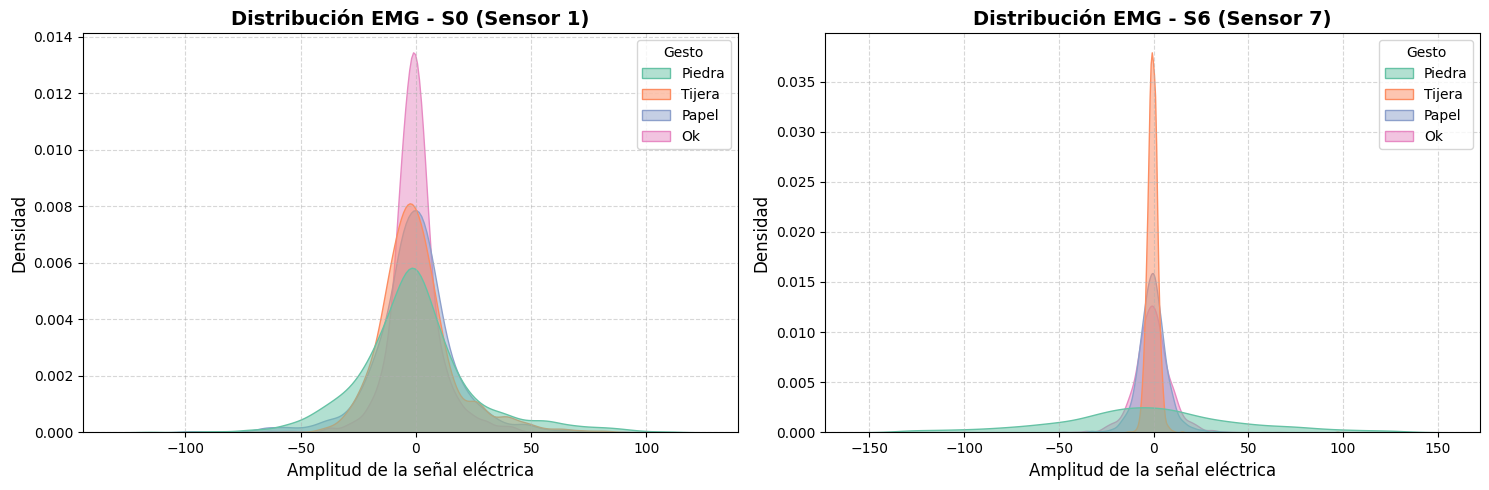

In [23]:
canal_1 = df.columns[0]  # Primer sensor
canal_2 = df.columns[6]  # Octavo sensor
columna_etiqueta = df.columns[-1]

nombres_gestos = {0: 'Piedra', 1: 'Tijera', 2: 'Papel', 3: 'Ok'}
df_temp = df.copy()
df_temp['Gesto'] = df_temp[columna_etiqueta].map(nombres_gestos)

# Graficas
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# 1
sns.kdeplot(data=df_temp, x=canal_1, hue='Gesto', fill=True, 
            palette='Set2', alpha=0.5, ax=axes[0], warn_singular=False)
axes[0].set_title(f'Distribución EMG - {canal_1} (Sensor 1)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amplitud de la señal eléctrica', fontsize=12)
axes[0].set_ylabel('Densidad', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2
sns.kdeplot(data=df_temp, x=canal_2, hue='Gesto', fill=True, 
            palette='Set2', alpha=0.5, ax=axes[1], warn_singular=False)
axes[1].set_title(f'Distribución EMG - {canal_2} (Sensor 7)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amplitud de la señal eléctrica', fontsize=12)
axes[1].set_ylabel('Densidad', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Estadísticas

In [24]:
# Solo 8 columnas (1 por canal) para no saturar la tabla
resumen_stats = df.iloc[:, 0:8].describe(percentiles=[.10, .25, .50, .75, .90]).T

# Asimetria: 0 = normal
asimetria = df.iloc[:, 0:8].skew() 
resumen_stats['asimetría'] = asimetria

columnas_ordenadas = ['mean', 'std', 'asimetría', 'min', '10%', '25%', '50%', '75%', '90%', 'max']
resumen_stats = resumen_stats[columnas_ordenadas]

# Tabla
display(resumen_stats.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'asimetría']))

,mean,std,asimetría,min,10%,25%,50%,75%,90%,max
S0,-0.520380,18.566709,0.531243,-116.000000,-19.000000,-9.000000,-1.000000,7.000000,18.300000,111.000000
S1,-0.726837,11.766878,-0.738995,-104.000000,-10.000000,-4.000000,-1.000000,3.000000,10.000000,90.000000
S2,-0.739082,4.989944,0.195186,-33.000000,-6.000000,-3.000000,-1.000000,2.000000,5.000000,34.000000
S3,-0.729748,7.441675,-0.886209,-75.000000,-8.000000,-4.000000,-1.000000,3.000000,7.000000,55.000000
S4,-0.159103,17.850402,-0.154362,-121.000000,-21.000000,-10.000000,0.000000,10.000000,21.000000,92.000000
S5,-0.554890,25.809528,0.160392,-122.000000,-31.000000,-15.000000,-1.000000,13.000000,30.000000,127.000000
S6,-1.272649,25.089972,-0.101045,-128.000000,-18.000000,-6.000000,-1.000000,4.000000,15.000000,127.000000
S7,-0.661843,15.408896,0.097727,-128.000000,-16.000000,-8.000000,-1.000000,6.000000,15.000000,126.000000
